# Transfer Learning

Transfer Learning is leveraging a working model's existing architecture and learned patterns for our own problem .

There are two main benefits .

* Can leverage an existing neural network architecture proven to work on problems similar to our own .
* Can leverage an working neural network architecture which has already learn patterns on similar data to our own , then we can adapt those patterns to our own data .  

In [2]:
# Check if we are using a GPU
!nvidia-smi

Tue Feb 24 19:09:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import zipfile
# Get data (10% of 10 food classes from Food101)
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip

# Unzip the download file
zip_ref = zipfile.ZipFile("10_food_classes_10_percent.zip")

zip_ref.extractall()

zip_ref.close()

--2026-02-24 19:09:26--  https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.10.207, 142.251.12.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.10.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 168546183 (161M) [application/zip]
Saving to: ‘10_food_classes_10_percent.zip’

10_food_classes_10_ 100%[===================>] 160.74M  22.6MB/s    in 8.5s    

2026-02-24 19:09:35 (18.9 MB/s) - ‘10_food_classes_10_percent.zip’ saved [168546183/168546183]



In [4]:
import os

# Walk throught 10 percent data directory and list number of files
for dirpath , dirnames , filenames in os.walk("10_food_classes_10_percent"):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}' .")

There are 2 directories and 0 images in '10_food_classes_10_percent' .
There are 10 directories and 0 images in '10_food_classes_10_percent/train' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/fried_rice' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings' .
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak' .
There are 0 directories and 75 images in '10_food_classes_10_perc

## Creating data loaders (preparing the data)

We'll use the `ImageDataGenerator` class to load in our images in batches .

In [5]:
# Setup data inputs 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SHAPE = (244 , 244)
BATCH_SIZE = 32

train_dir = "10_food_classes_10_percent/train/"
test_dir = "10_food_classes_10_percent/test/"

train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

print("Training images :")
train_data_10_percent = train_datagen.flow_from_directory(train_dir,
                                                          target_size=IMAGE_SHAPE,
                                                          batch_size=BATCH_SIZE,
                                                          class_mode="categorical")

print("Testing images :")
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMAGE_SHAPE,
                                             batch_size=BATCH_SIZE,
                                             class_mode="categorical")

Training images :
Found 750 images belonging to 10 classes.
Testing images :
Found 2500 images belonging to 10 classes.


## Setting up callbacks (things to run whilst our model trains)

Callbacks are extra functionality you can add to your models to be performed during or after training . Some of the most popular callbacks :

* Tracking experiments with the TensorBoard callback
* Model checkpoint with the ModelCheckpoint callback 
* Stopping a model from training (before it trains too long and overfits) with the EarlyStopping callback


In [6]:
# Create TensorBoard callback (functionized because we need to crete a new one for each model)
import datetime
import tensorflow as tf

def create_tensorboard_callback(dir_name , experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
    tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)
    print(f"Saving Tensorborad log file to : {log_dir}")
    return tensorboard_callback

In [21]:
# Import dependencies
from keras import layers
# Crete model fucntion to create a model from a URL 
def create_model(model_base , num_classes=10) :
    """Takes a pretrained Keras model and creates a Keras Sequential model with it.
    
       Args :
              model_base (tf.keras.Model) : A pretrained Keras model.
              num_classes (int) : Number of output neurons in the output layer ,
                                  should be equal to number of target classes , default 10.
       Returns :
              An uncompiled Keras Sequential model with model_base as feature extractor layer and Dense output layer with num_classes output neurons.  
    """

    # Download the pretrained model and save it as a Keras layer
    model_base.trainable = False
    
    # Create our own model
    model = tf.keras.Sequential([
        model_base,
        layers.Dense(num_classes , activation="softmax" , name="output_layer")
    ])

    return model 

In [16]:
keras_resnet_model = tf.keras.applications.ResNet50V2(include_top=False , weights="imagenet" , input_shape=IMAGE_SHAPE+(3,) , pooling="avg")

In [22]:
resnet_model = create_model(keras_resnet_model , num_classes=train_data_10_percent.num_classes)

In [23]:
resnet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50v2 (Functional)         │ (None, 2048)           │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        20,490 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,585,290 (89.97 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [24]:
# Compile our resnet model 

resnet_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                     optimizer=tf.keras.optimizers.Adam(),
                     metrics=["accuracy"])

In [26]:
# Fit the model 
resnet_model.fit(
    train_data_10_percent , 
    epochs=5 , 
    steps_per_epoch=len(train_data_10_percent) , 
    validation_data=test_data , 
    validation_steps=len(test_data) ,
    callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub" , experiment_name="resnet50v2")]
)

Saving Tensorborad log file to : tensorflow_hub/resnet50v2/20260224-193804


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 35s 953ms/step - accuracy: 0.2080 - loss: 2.3536 - val_accuracy: 0.6408 - val_loss: 1.2253
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 408ms/step - accuracy: 0.7183 - loss: 0.9919 - val_accuracy: 0.7252 - val_loss: 0.8842
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 421ms/step - accuracy: 0.7754 - loss: 0.7427 - val_accuracy: 0.7796 - val_loss: 0.7420
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 432ms/step - accuracy: 0.8638 - loss: 0.5487 - val_accuracy: 0.7764 - val_loss: 0.7136
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 417ms/step - accuracy: 0.8798 - loss: 0.4357 - val_accuracy: 0.7880 - val_loss: 0.6621


In [29]:
import matplotlib.pyplot as plt 

# Function to plot loss curves 
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    
    Args : 
              history : TensorFlow model history object.

    Returns : 
            Plots of training and validation loss and accuracy metrics.
    """

    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    accuracy = history.history["accuracy"]
    val_accuracy = history.history["val_accuracy"]

    epochs = range(len(history.history["loss"]))
    
    # Plot loss 
    plt.plot(epochs , loss , label="training_loss")
    plt.plot(epochs , val_loss , label="validation_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy 
    plt.figure()
    plt.plot(epochs , accuracy , label="training_accuracy")
    plt.plot(epochs , val_accuracy , label="validation_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

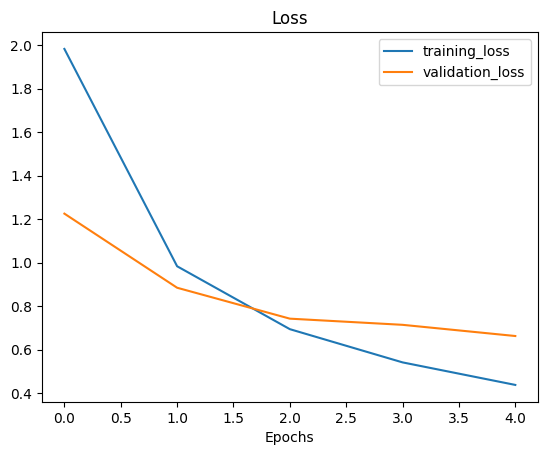

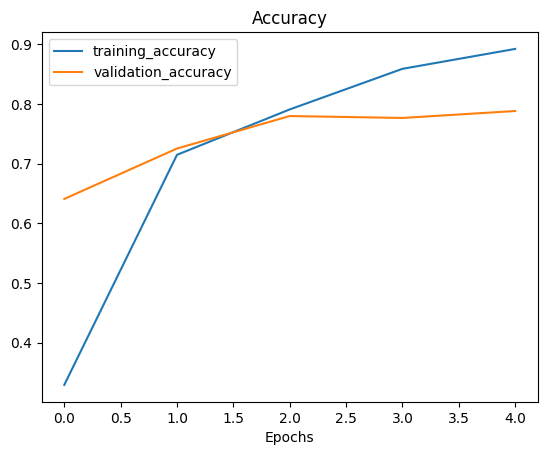

In [30]:
plot_loss_curves(resnet_model.history)

In [31]:
keras_efficientnet_model = tf.keras.applications.EfficientNetB0(include_top=False , weights="imagenet" , input_shape=IMAGE_SHAPE+(3,) , pooling="avg")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [32]:
efficientnet_model = create_model(keras_efficientnet_model , num_classes=train_data_10_percent.num_classes)

In [33]:
efficientnet_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,062,381 (15.50 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [34]:
# Compile the efficientnet model
efficientnet_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(),
                             optimizer=tf.keras.optimizers.Adam(),
                             metrics=["accuracy"])

In [36]:
# Fit the efficientnet model
efficientnet_model.fit(
    train_data_10_percent,
    epochs=5,
    steps_per_epoch=len(train_data_10_percent),
    validation_data=test_data,
    validation_steps=len(test_data),
    callbacks=[create_tensorboard_callback(dir_name="tensorflow_hub" , experiment_name="efficientnetb0")]
)

Saving Tensorborad log file to : tensorflow_hub/efficientnetb0/20260224-200051
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.1011 - loss: 2.3321 - val_accuracy: 0.1000 - val_loss: 2.3546
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 363ms/step - accuracy: 0.1035 - loss: 2.3312 - val_accuracy: 0.1000 - val_loss: 2.3347
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.0950 - loss: 2.3247 - val_accuracy: 0.1000 - val_loss: 2.3296
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 371ms/step - accuracy: 0.1052 - loss: 2.3304 - val_accuracy: 0.1000 - val_loss: 2.3218
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 532ms/step - accuracy: 0.1114 - loss: 2.3256 - val_accuracy: 0.1000 - val_loss: 2.3168


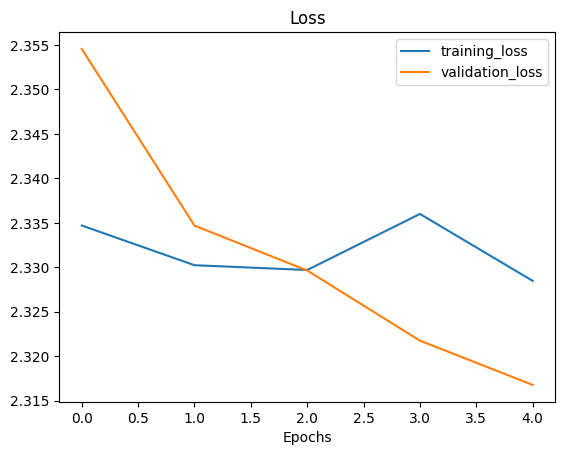

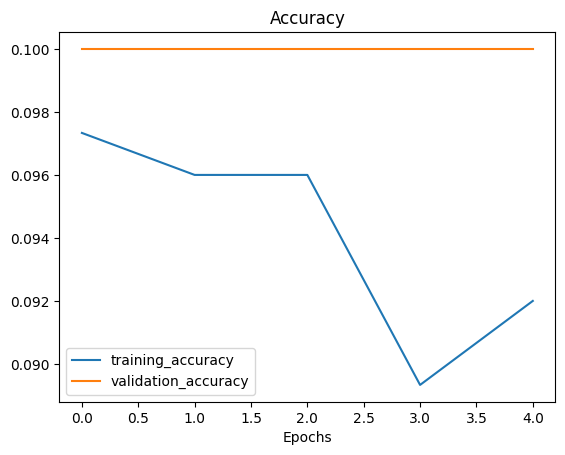

In [37]:
plot_loss_curves(efficientnet_model.history)